# US Home Prices, Inventory, and Mortgage Index (2016 – Present)

## US Housing Market Dynamics: Actual Figures, Inventory Growth, & Mortgage Rates

### Description

This notebook provides a technical visualization of U.S. macro housing trends. It utilizes data from the Federal Reserve Economic Data (FRED) to analyze and cross-reference:

- **30-Year Fixed Rate Mortgage (`MORTGAGE30US`):** Weekly average fixed mortgage rates and their year-over-year rate changes.
- **Active Listing Count (`ACTLISCOUUS`):** Monthly total housing inventory levels coupled with a 3-month moving average of month-over-month growth.
- **Median Sales Price of Houses Sold (`MSPUS`):** Quarterly median home sales pricing contrasted against corresponding macro interest rates.

The analysis tracks both actual index figures and underlying changes to highlight shifts in structural supply, affordability, and macro-driven real estate trends.

---

## Objectives

- Analyze housing supply elasticity and inventory trends from 2016 to the present day.
- Compare home price trajectories with the direct velocity of mortgage rate changes.
- Identify inflection points where interest rate spikes explicitly cool down or bottleneck active listings.
- Provide a time-logged macroeconomic analysis of the US housing landscape.

---

## Data Sources

- Federal Reserve Economic Data (FRED)
  - `MORTGAGE30US`: 30-Year Fixed Rate Mortgage Average in the United States (Weekly)
  - `ACTLISCOUUS`: Housing Inventory: Active Listing Count in the United States (Monthly)
  - `MSPUS`: Median Sales Price of Houses Sold for the United States (Quarterly)

## Pre-Processing

### Install System Dependencies

In [2]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [3]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Standard Unit Initial Timeframe

In [4]:
start = datetime(2016, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

## U.S. 30-yr Fixed Rate Mortgage Net Changes (2016 - Present)

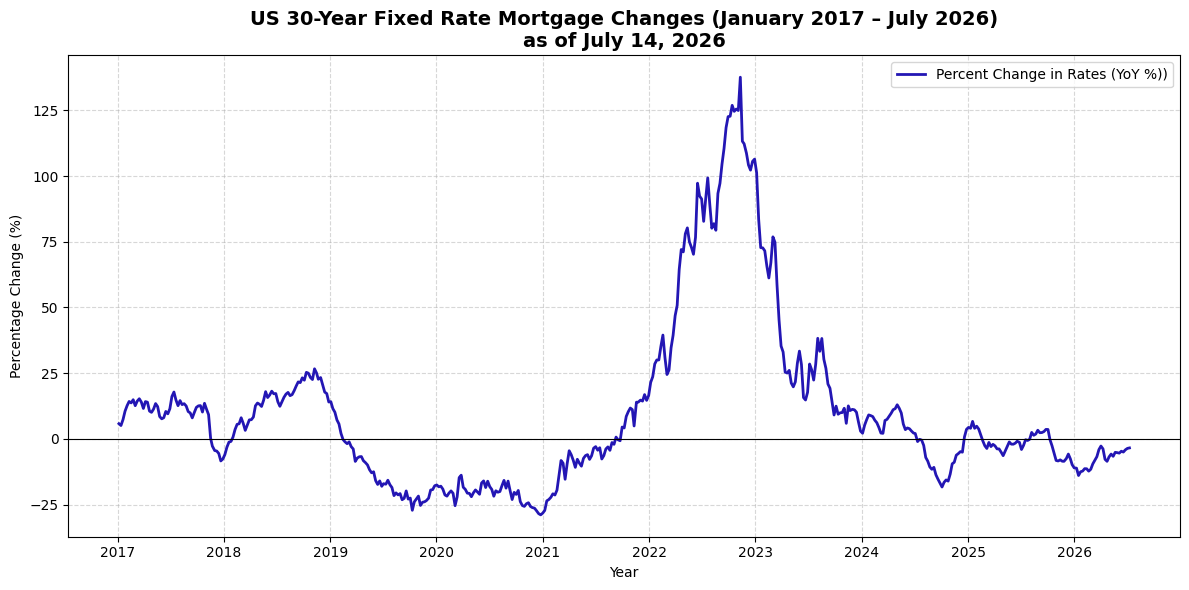

In [5]:
# Source : FRED
df_fixed = web.DataReader('MORTGAGE30US', 'fred', start, end)
df_yoy = df_fixed.pct_change(periods = 52) * 100

# Plotting
plt.figure(figsize = (12, 6))
plt.plot(df_yoy.index, df_yoy['MORTGAGE30US'], label = 'Percent Change in Rates (YoY %))', color = "#2316b4", linewidth =2)

plt.title(f'US 30-Year Fixed Rate Mortgage Changes ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, 
            color = 'black', 
            linewidth = 0.8, 
            linestyle = '-')
plt.grid(True, 
         which = 'both', 
         linestyle = '--', 
         alpha = 0.5)
plt.legend()
plt.tight_layout()

plt.show()

## US Housing Inventory and Net Change (2016 - Present)

<Figure size 1600x600 with 0 Axes>

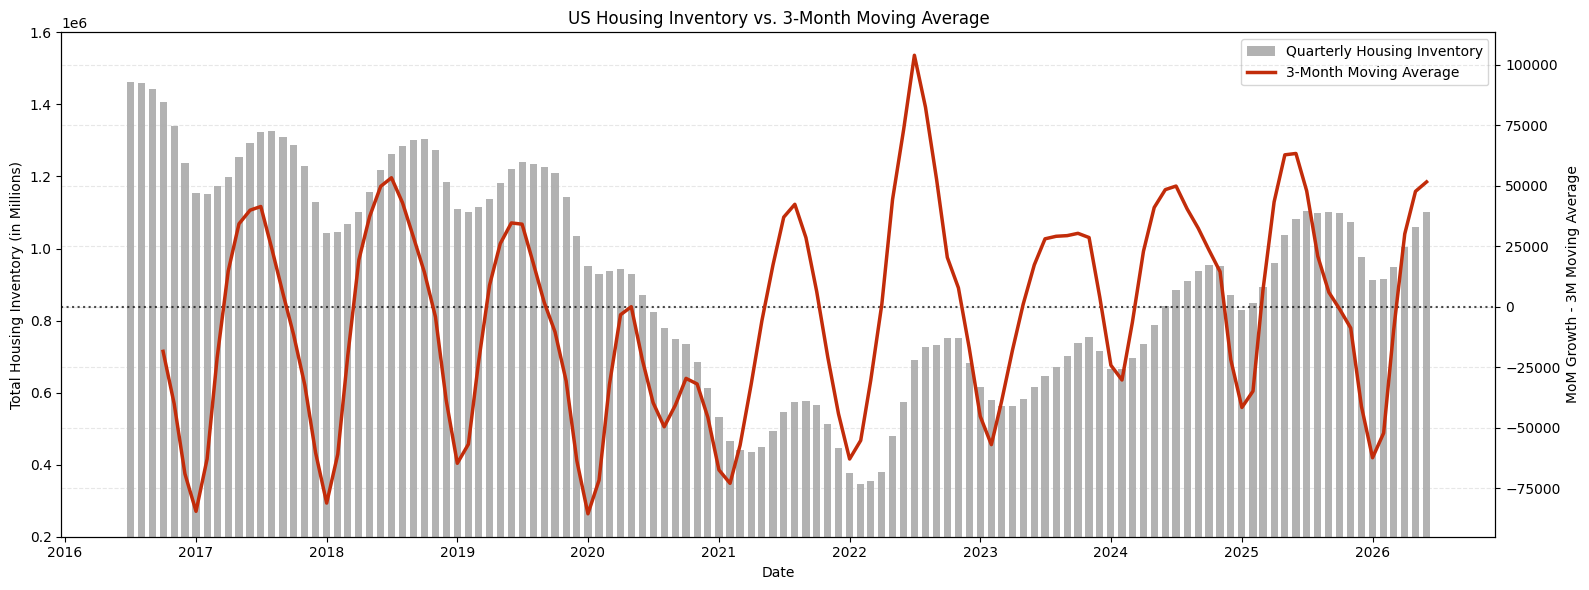

In [6]:
# Source : FRED
df = web.DataReader("ACTLISCOUUS", "fred", start, end)

df["housing_growth"] = df["ACTLISCOUUS"].diff()
df["ma_3"] = df["housing_growth"].rolling(3).mean()

df_focus = df[(df.index >= start)]

plt.figure(figsize = (16, 6)) 

fig, ax1 = plt.subplots(figsize = (16, 6))

# inventory bar graph
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Housing Inventory (in Millions)", color = "black")
ax1.tick_params(axis = "y", labelcolor = "black")
ax1.set_ylim(200000, 1600000)
ax1.bar(
    df_focus.index,
    df_focus["ACTLISCOUUS"],
    color = "grey",
    width = 20,
    alpha = 0.6,
    label = "Quarterly Housing Inventory",
)

# copy left axis
ax2 = ax1.twinx()

# inventory moving average
ax2.set_ylabel("MoM Growth - 3M Moving Average", color = "black")
ax2.tick_params(axis = "y", labelcolor = "black")
ax2.axhline(0, color = "black", 
            linestyle = ":", 
            linewidth = 1.5, 
            alpha = 0.7)
ax2.plot(
    df_focus.index,
    df_focus["ma_3"],
    color = "#c22c0a",
    linewidth = 2.5,
    label = "3-Month Moving Average",
)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title(
    "US Housing Inventory vs. 3-Month Moving Average"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper right")

plt.grid(axis = "y", linestyle = "--", alpha = 0.3)
fig.tight_layout()

plt.show()


### 30 year Mortgage Rates vs. Median Home Prices (2016 - Present)

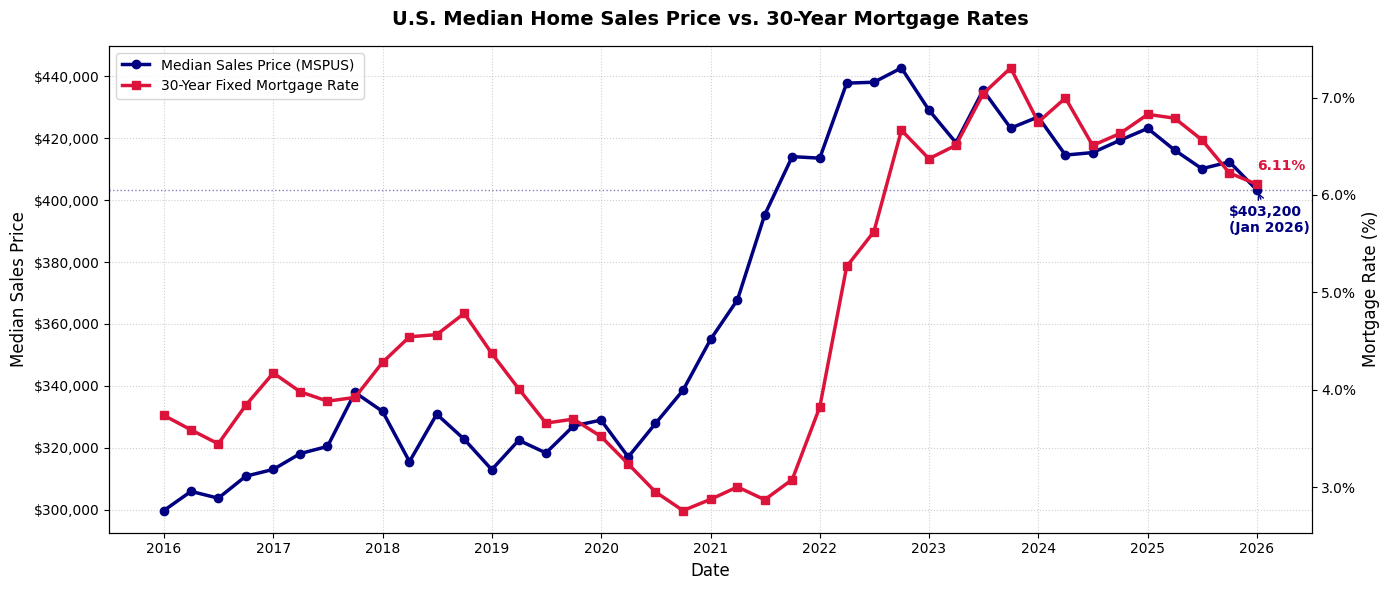

In [7]:
# Source : FRED
df_median = web.DataReader("MSPUS", "fred", start, end)  # Quarterly
df_mortgage = web.DataReader("MORTGAGE30US", "fred", start, end)  # Weekly

# pre-processing
df_quarterly = pd.DataFrame(index = df_median.index)
df_quarterly["Median_Sales_Price"] = df_median["MSPUS"]
df_quarterly["Avg_Mortgage_Rate"] = df_mortgage.resample("QS").mean()

df_quarterly.dropna(inplace = True)

# plotting: axis I
fig, ax1 = plt.subplots(figsize = (14, 6))

ax1.plot(
    df_quarterly.index,
    df_quarterly["Median_Sales_Price"],
    color = "navy",
    linewidth = 2.5,
    marker = "o",
    label = "Median Sales Price (MSPUS)",
)
ax1.set_xlabel("Date", fontsize = 12)
ax1.set_ylabel("Median Sales Price", color = "black", fontsize = 12)
ax1.tick_params(axis = "y", labelcolor = "black")
ax1.yaxis.set_major_formatter("${x:,.0f}")  # Formats as $400,000

# plotting: axis II
ax2 = ax1.twinx()
ax2.plot(
    df_quarterly.index,
    df_quarterly["Avg_Mortgage_Rate"],
    color = "crimson",
    linewidth = 2.5,
    marker = "s",
    label = "30-Year Fixed Mortgage Rate",
)
ax2.set_ylabel("Mortgage Rate (%)", color = "black", fontsize = 12)
ax2.tick_params(axis = "y", labelcolor = "black")
ax2.yaxis.set_major_formatter("{x:.1f}%")  # Formats as 6.5%

# formatting: plot
plt.title(
    "U.S. Median Home Sales Price vs. 30-Year Mortgage Rates",
    fontsize = 14,
    fontweight = "bold",
    pad = 15,
)

# formatting: axis
ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


# merging
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper left")

# annotations
# median price
r_val = df_quarterly["Median_Sales_Price"].dropna().iloc[-1]
r_date = df_quarterly["Median_Sales_Price"].dropna().index[-1]

ax1.annotate(
    f"${r_val:,.0f}\n({r_date.strftime('%b %Y')})", 
    xy=(r_date, r_val), 
    xytext=(-20, -30), # Adjust positioning as needed
    textcoords="offset points", 
    ha='left', 
    weight='bold', 
    color='navy',
    arrowprops=dict(arrowstyle="->", color="navy")
)

ax1.axhline(y=r_val, color="navy", linestyle=":", linewidth=1, alpha=0.5)

# mortgage rates
r_val_mortgage = df_quarterly["Avg_Mortgage_Rate"].dropna().iloc[-1]
r_date_mortgage = df_quarterly["Avg_Mortgage_Rate"].dropna().index[-1]

ax2.annotate(
    f"{r_val_mortgage:.2f}%", 
    xy=(r_date_mortgage, r_val_mortgage), 
    xytext=(0, 10),            # Adjust offset to avoid overlapping ax1's annotation
    textcoords="offset points", 
    ha='left', 
    color='crimson',            # Match your ax2 plot color
    weight='bold'
)

ax1.grid(True, linestyle = ":", alpha = 0.6)
fig.tight_layout()

plt.show()

# Conclusions and Observations

### Housing – 25 June 2026

On Monday, June 22, 2026, the United States Senate passed the 21st Century ROAD to Housing Act by an overwhelming majority of 85-5.

The next day, the very same bill reached the floor of the United State House of Representatives with a slightly smaller majority, by percentage, by a 358-32 vote.

In congressional chambers, the dissenting votes were cast by members of the Republican Party.

On Wednesday, June 24, 2026, United States President, Donald J. Trump, was scheduled to sign the bipartian bill into law. 

Abruptly, the real estate mogul cancelled the bill's signing into law, refusing to sign. The President instead opted to leverage the bill signing against his desire to pass the proposed SAVE America Act.

**The absurdity of the situation points to an increasing mountain of evidence concerning the nation's leadership choices.**

H.R. 6644 passed  ***both*** chambers and currently awaits executive action by ways of signature or veto. 

In the instance of veto, the bill is *highly* likely to survive as it previously passed the 60% majority, shattering the threshold to bypass executive authority. 

Should the Trump administration continue to stall, the bill is automatically enactted as a matter of constituional law, provided congress is still in session.

The next congressional recess is on July 11, 2026.

**Meanwhile, regarding voter suppression...**

H.R. 7296 has been grounded. While the House passed the bill 218-213 on February 11, 2026, the Senante is unable to enter 60 votes, which would otherwise bypass an active Democratif fillibsuter.

In order for Senate Republicans to possess a 60-vote majority, they would have already sworn in several Republican Senantors in 2027, defeating the purpose of passing the bill ahead of congressional midterms.

#### <u>So about the housing bill...</u>

Home prices after Q1 2026 reached **$403,600** at an annual interest rate of **6.11%,** much higher than pre-pandemic figures in January 2019 at **$317,200** and **3.7%** respectively.

There is good news in that these figures are *down* from peaks after pandemic recovery at **438,600** in June 2025 and **7.79%** in October 2023.

The congressional housing bill, currently doing its best impression of a human statue, is designed to increase housing supply and place limits on institutional buyers. 

The bill aims to streamline homebuildig processes and reqard municipalities thatt voluntarily update zoning laws, reduce regualtory barriers, and expediate local home building. 

In May 2026, the United States possessed **1,058,693** active listings, an increase of **47,658.67** units over the previous three months. 

Economists and policy analysts project the passing and execution of this bill will result in an additonal 2.5 million availbe houses over the next 10 years, and has greater implications beyond. 

Some predictions show national home price growth flatttening to 2% - 3% annually, on pace with the inflationary target of the Federal Reserce.

In metro areas, this should appear in prices of starter homes receeding by 3% to 7%, without diminsishing the value of the property in fact, over normalized projections, the bill is designed to marginally affect existing property values. 

The bill is intended to dilute housing supply with adequate new constructions at prices allowing median wages to catch up to median home prices. 

Over time, the expected growth will steadily lower the ratio of U.S. home price-to-income ratio, into a more historically normal ratio.

For comparrison, purhcasing a home **today,** for $403,600 at 6.11% intrest over a standard 30-year conventional mortage turns out to ***$881,424.91*** after 30 years; about **$2,448.40/month.** 

Purchasing a house at $317,200 at 4.46% interest in <u>January 2019</u> came out to **$575,883.25** after 30 years and **$1,599.68/month.** 

A difference of <u>$848.72/month</u>, <u>$10,184.64/year</u>, and <u>**$219,141.66** total liifetime interest</u>.

*Amazing to think just how far we came. Time will tell.*

___

**Thank you for reading, I don't own a house yet. At these prices? Have you seen the median wages lately?**

**In case you haven't, I've updated <u>U.S. Real GPD and Wage Growth</u>. Remember that the next time you find yourself negotiating a salary.**

___

#### Update Schedule

- ***Rates - Jul 9, 2026***
    1. `MORTGAGE30US`: **30-Year Fixed Rate Mortgage Average - Weekly**

- ***Inventory - Aug 6, 2026***

    2. `ACTLISCOUUS`: **Housing Inventory - Monthly**

- ***Prices - Jul 24, 2026***

    3. `MSPUS`: **Median Sales Price - Quarterly**

#### Data Changelog / Notes

1. **US 30-Year Fixed Rate Mortgage Changes**
    - `pct_change` in `df_yoy`: Mortgae rate buckets misclassified as previous 12 weeks. 
        - *Correctetd to 12 month intervals over previous 52 weeks.*

#### ***Review and analysis publishing on Friday, July 24, 2026, at 1:30 P.M. Pacific Time.***